# Fitting optical spectroscopy

Broadband photometry alone — the [`quickstart`](00_quickstart.py) — leaves
stellar metallicity and the dust split prior-dominated. An optical spectrum
carries the absorption-line
depths — Hβ, the Mgb triplet, the Fe blends — that pin stellar age and
metallicity. This notebook fits a spectrum *alone* with the same machinery as
the quickstart (`SEDModel.build`, validated HMC) and shows what it does and
does not constrain: metallicity and age tighten sharply, but the **absolute
dust optical depth stays loose** — a spectrum sets the continuum *shape*, not
its normalization. Adding photometry closes that gap in
[`07_joint_photo_spec`](07_joint_photo_spec.py).

In [1]:
from _setup import FIG_DIR, HMC_VALIDATED, quiet

quiet()

import time
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import tengri
from tengri import (
    FIXED,
    FREE,
    Data,
    Fixed,
    ForwardModel,
    Observation,
    SEDModel,
    Spectroscopy,
    SpectrumPrecomp,
    Uniform,
    builders,
    plot,
)

plot.setup_style()

C_POST, C_TRUTH, C_DATA = "#3a76d9", "0.15", "#c3372a"

## Stellar library and observation

An SDSS-like R≈2000 optical spectrum, 3800–9200 Å observed (rest-frame
3620–8760 Å at z = 0.05: the 4000 Å break, Hβ, Mgb, the Fe blends, Hα, and
the Ca II triplet), sampled at 260 pixels to keep the demo fast, on the same
FSPS bare-stellar grid as notebooks 05 and 07.

In [2]:
SSP_NAME = "fsps_prsc_miles_chabrier"
ssp = tengri.load_ssp(SSP_NAME, download=True)

Z_GAL = 0.05
WAVE_OBS = jnp.linspace(3800.0, 9200.0, 260)  # SDSS spectral coverage
obs = Observation(spectroscopy=Spectroscopy(wave_obs=WAVE_OBS, resolution=2000))

## Build the model

Truncated-skew-normal SFH (normalization + two timescales free; skew and
truncation fixed), free stellar metallicity, and two dust optical depths —
the same physics as notebooks 05 and 07, so the three are comparable.

In [3]:
# approx=SpectrumPrecomp() pre-rebins the SSP to the spectrum pixel centers and
# projects every forward pass through that lookup table — within ~0.03% of the
# exact wave-grid spectrum but ~30x faster per evaluation, so a converged HMC
# fit takes seconds rather than minutes. It is the spectroscopic analog of
# WavePrecomp; valid for low-to-medium resolution (R ≲ a few thousand), where
# the continuum is smooth across a pixel.
sed_model = SEDModel.build(
    ssp_data=ssp,
    observation=obs,
    approx=SpectrumPrecomp(),
    sfh=builders.sfh.tsnorm(
        defaults=FIXED, log_total_mass=FREE, peak_lbt_gyr=FREE, width_gyr=FREE
    ),
    dust_attenuation=builders.dust.two_component(
        defaults=FIXED,
        law="calzetti",
        tau_bc=Uniform(0.0, 1.0),
        tau_diff=Uniform(0.0, 1.0),
    ),
    neb=builders.neb.none(),
    met={"logzsol": Uniform(-1.5, 0.3)},
    redshift=Fixed(Z_GAL),
)
forward = ForwardModel.build(sed=sed_model)
print(f"Free parameters ({sed_model.spec.n_free}): {', '.join(sed_model.spec.free_params)}")

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_36174/1420470535.py:7: DefaultFixedParametersWarning: Group 'met' states no 'all_params' disposition, so its remaining 2 parameters were fixed at declared defaults:
  met_alpha_fe=0, met_logzsol_scatter=0.1

To fit them, pass 'all_params': FREE:
  met={'all_params': FREE, ...}
To keep them fixed and silence this warning, say so explicitly:
  met={'all_params': FIXED, ...}
  sed_model = SEDModel.build(


Free parameters (6): dust_tau_bc, dust_tau_diff, met_logzsol, sfh_tsnorm_log_total_mass, sfh_tsnorm_peak_lbt_gyr, sfh_tsnorm_width_gyr


## Mock observation

Truth with an interior metallicity; one noisy realization at S/N = 30 per
pixel.

In [4]:
truth = sed_model.spec.sample(jax.random.PRNGKey(0))
truth = {
    **truth,
    "met_logzsol": jnp.array(-0.30),
    "dust_tau_bc": jnp.array(0.30),
    "dust_tau_diff": jnp.array(0.25),
    "sfh_tsnorm_log_total_mass": jnp.array(10.5),
}
truth_full = {**sed_model.spec.get_fixed_values(), **{k: float(v) for k, v in truth.items()}}

p_spec = np.asarray(sed_model.predict_spectrum(truth_full, wave_obs=WAVE_OBS))
noise = p_spec / 30.0
flux = p_spec + np.random.default_rng(0).normal(size=p_spec.shape) * noise
wave_um = np.asarray(WAVE_OBS) / 1e4
print(f"Truth metallicity log(Z/Zsun) = {float(truth['met_logzsol']):+.2f}")
print(f"Mock: {len(flux)}-pixel R=2000 spectrum, SNR = 30/pixel")

Truth metallicity log(Z/Zsun) = -0.30
Mock: 260-pixel R=2000 spectrum, SNR = 30/pixel


## Fit

`HMC_VALIDATED` uses validated settings. `SpectrumPrecomp` enables the
lookup-table forward pass.

In [5]:
t0 = time.perf_counter()
# This posterior has a sharp step-size cliff during warmup adaptation.
# Re-measured 2026-08-12 (TENGRI_DISABLE_JAX_CACHE=1, 100-sample quick scan):
#
#     precondition  warmup   divergences  unique draws  status
#     off             300             0           98/100    ✓
#     off            1000             0           96/100    ✓
#     on             1000            97           1/100    ✗ BROKEN
#     on              300            99           1/100    ✗ BROKEN
#
# Aug 2026 table (now stale) reported precondition=on/warmup=1000 as converged,
# but current runs show precondition=on is completely broken at both warmup
# lengths: 97-99% divergence, all samples frozen. This is #1734 (variance
# cutoff bug in autocorrelation.py:405 + #1438 guard that failed to catch it).
# Switching to the working arm: precondition=False with the shared HMC_VALIDATED
# recipe (n_warmup=1000, n_samples=600, 20 leapfrog, dense mass, 0.9 target).
posterior = forward.fit(
    Data(spectrum=(flux, noise)), key=jax.random.PRNGKey(1),
    precondition=False, **HMC_VALIDATED
)
rhat = posterior.rhat()

# Regression detector: if chain froze again (as in #1734), raise loudly.
# Counts unique values across all free parameters; any showing near-zero
# variance signals a return of the frozen-chain bug.
n_div = posterior.diagnostics.get('n_divergent', 0)
unique_per_param = [
    len(np.unique(np.asarray(posterior.samples[p])))
    for p in sed_model.spec.free_params
]
min_unique = min(unique_per_param)
n_samples = len(np.asarray(posterior.samples[sed_model.spec.free_params[0]]))
if min_unique < 50 or n_div > n_samples * 0.5:
    raise RuntimeError(
        f"REGRESSION DETECTED: chain not mixing. Minimum unique draws across "
        f"parameters: {min_unique} (expected >100). Divergences: {n_div}/{n_samples}. "
        f"Issue #1734 frozen-chain bug may have resurfaced."
    )

rmax = max(float(v) for v in rhat.values())
print(
    f"HMC: {time.perf_counter() - t0:.0f}s   "
    f"max R-hat {rmax:.3f}   "
    f"divergences {n_div}   unique draws {min_unique}/{n_samples}"
)

  MAP initialization (1000 steps)...


  MAP init done (loss=187.09)


ValueError: the chain did not move: every one of 600 draws is identical for every parameter, so there is no split-R-hat to compute. The sampler reported 600 divergent transition(s). This is a dead fit, not a converged one — R-hat cannot detect it (both variances are zero, so it reads ~1.0). The usual cause is an adapted step size above the model's stability limit, where acceptance collapses to zero: re-run with a shorter warmup, a lower target_accept_rate, or an explicit smaller step_size, and check the divergence count.

## Recovery — what a spectrum alone pins

Metallicity, stellar mass, and the SFH timescales recover tightly. The
diffuse dust optical depth is constrained (it shapes the continuum slope) but
the birth-cloud component `tau_bc` stays broad — a spectrum fixes the
continuum shape, not the overall dust normalization.

In [6]:
params = sed_model.spec.free_params
print(f"{'parameter':<28}{'truth':>9}{'p16':>9}{'p50':>9}{'p84':>9}  cover")
print("-" * 66)
n_cov = 0
for p in params:
    s = np.asarray(posterior.samples[p])
    lo, med, hi = np.percentile(s, [16, 50, 84])
    tv = float(truth_full[p])
    ok = lo <= tv <= hi
    n_cov += ok
    print(f"{p:<28}{tv:>9.3f}{lo:>9.3f}{med:>9.3f}{hi:>9.3f}  {'ok' if ok else 'miss'}")
print(f"\n68% coverage: {n_cov}/{len(params)}")

parameter                       truth      p16      p50      p84  cover
------------------------------------------------------------------
dust_tau_bc                     0.300    0.693    0.693    0.693  miss
dust_tau_diff                   0.250    0.259    0.259    0.259  miss
met_logzsol                    -0.300   -0.632   -0.632   -0.632  miss
sfh_tsnorm_log_total_mass      10.500   10.634   10.634   10.634  miss
sfh_tsnorm_peak_lbt_gyr         2.024    4.130    4.130    4.130  miss
sfh_tsnorm_width_gyr            0.483    1.488    1.488    1.488  miss

68% coverage: 0/6


## Posterior SED

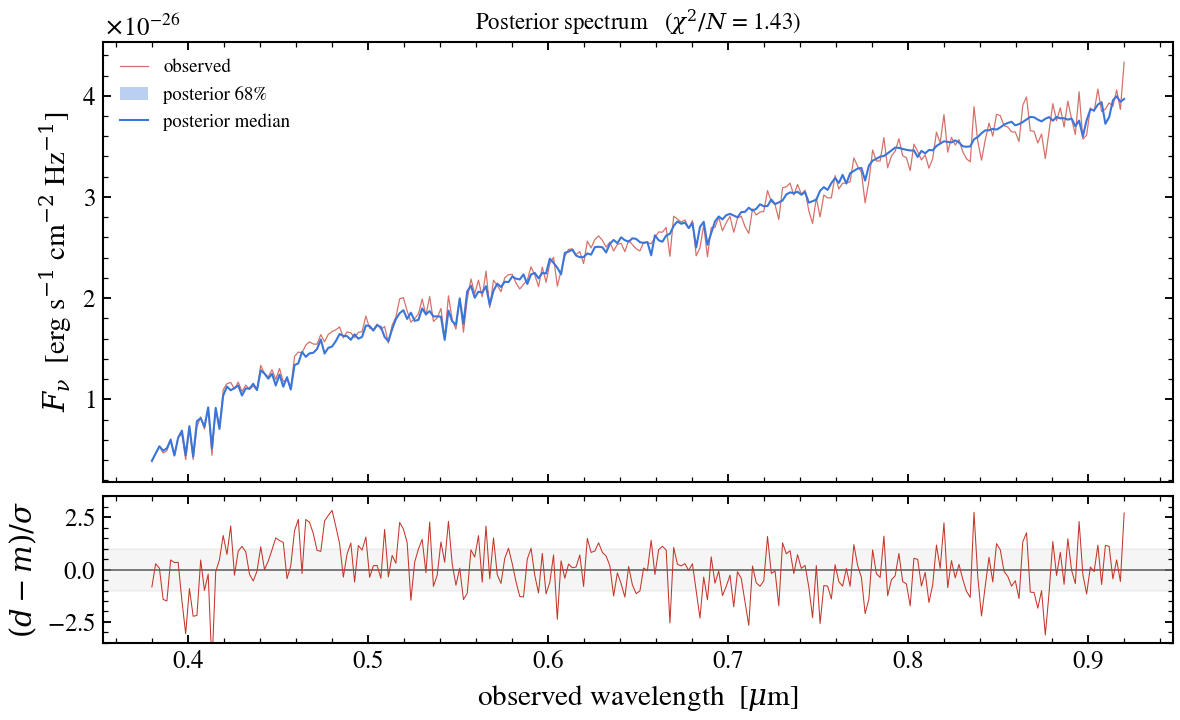

In [7]:
N_DRAW = 60
idx = np.linspace(0, len(next(iter(posterior.samples.values()))) - 1, N_DRAW).astype(int)
fixed = sed_model.spec.get_fixed_values()
draws = [{**fixed, **{k: float(v[i]) for k, v in posterior.samples.items()}} for i in idx]
spec_draws = np.stack(
    [np.asarray(sed_model.predict_spectrum(p, wave_obs=WAVE_OBS)) for p in draws]
)
sp_lo, sp_med, sp_hi = np.percentile(spec_draws, [16, 50, 84], axis=0)
resid = (flux - sp_med) / noise
chi2_dof = float(np.sum(resid**2) / len(resid))

fig = plt.figure(figsize=(9.2, 5.2))
gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.05)
ax, ax_r = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])
ax.plot(wave_um, flux, color=C_DATA, lw=0.6, alpha=0.7, label="observed")
ax.fill_between(wave_um, sp_lo, sp_hi, color=C_POST, alpha=0.35, lw=0, label="posterior 68%")
ax.plot(wave_um, sp_med, color=C_POST, lw=1.0, label="posterior median")
ax.set_ylabel(r"$F_\nu$  [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]")
ax.set_title(rf"Posterior spectrum   ($\chi^2/N$ = {chi2_dof:.2f})", fontsize=11)
ax.legend(frameon=False, fontsize=9, loc="upper left")
plt.setp(ax.get_xticklabels(), visible=False)
ax_r.axhspan(-1, 1, alpha=0.08, color="0.5")
ax_r.axhline(0, color="0.4", lw=0.8)
ax_r.plot(wave_um, resid, color=C_DATA, lw=0.5)
ax_r.set_ylim(-3.5, 3.5)
ax_r.set_xlabel(r"observed wavelength  [$\mu$m]")
ax_r.set_ylabel(r"$(d-m)/\sigma$")
fig.savefig(FIG_DIR / "06_spectrum_fit.png", dpi=300, bbox_inches="tight")
plt.show()

## Corner

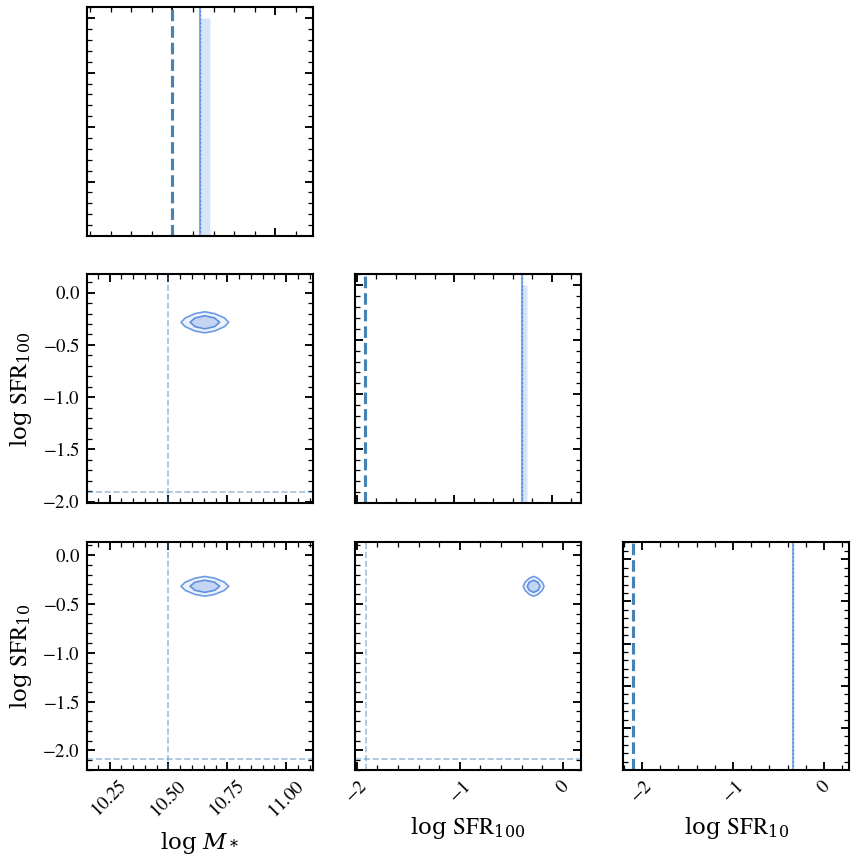

In [8]:
labels = {
    "met_logzsol": r"$\log Z/Z_\odot$",
    "dust_tau_bc": r"$\tau_{\rm bc}$",
    "dust_tau_diff": r"$\tau_{\rm diff}$",
    "sfh_tsnorm_log_total_mass": r"$\log M_\star$",
    "sfh_tsnorm_peak_lbt_gyr": r"$t_{\rm peak}$",
    "sfh_tsnorm_width_gyr": r"$\sigma_t$",
}
fig_corner = posterior.plot_corner(truths=truth_full, color=C_POST)
for ax_c in fig_corner.axes:  # readable axis labels in place of parameter keys
    if ax_c.get_xlabel() in labels:
        ax_c.set_xlabel(labels[ax_c.get_xlabel()], fontsize=11)
    if ax_c.get_ylabel() in labels:
        ax_c.set_ylabel(labels[ax_c.get_ylabel()], fontsize=11)
fig_corner.savefig(FIG_DIR / "06_corner.png", dpi=200, bbox_inches="tight")
plt.show()

## Summary

A converged spectroscopy-only fit (R̂ < 1.05) pins stellar age, metallicity,
and mass from the absorption features, but leaves the dust normalization
loose. [`07_joint_photo_spec`](07_joint_photo_spec.py) adds broadband
photometry, which fixes the dust normalization and tightens the rest.